# 2 — Option pricing, Greeks, and proving the implementation is right

Any pricing formula can be typed in. The interesting question is how you know
it is correct. This notebook prices European options, computes all five Greeks,
solves for implied volatility, and then **validates** the implementation two
ways that share no code with the closed form.

In [1]:
from risk_engine import (
    black_scholes_price, black_scholes_greeks,
    binomial_price, implied_volatility, put_call_parity_gap,
)

S, K, T, r, sigma = 100.0, 105.0, 1.0, 0.05, 0.20

call = black_scholes_price(S, K, T, r, sigma, "call")
put  = black_scholes_price(S, K, T, r, sigma, "put")
print(f"Call: {call:.6f}")
print(f"Put : {put:.6f}")

Call: 8.021352
Put : 7.900442


## Validation 1 — put-call parity

$$C - P = S e^{-qT} - K e^{-rT}$$

This identity is **model-free**: it follows from no-arbitrage alone, not from
Black-Scholes. If either the call or the put branch has a sign error, the
residual will not vanish. It is the single strongest correctness check
available for a pricer.

In [2]:
gap = put_call_parity_gap(call, put, S, K, T, r)
print(f"Parity residual: {gap:.2e}   (machine zero)")

Parity residual: 0.00e+00   (machine zero)


## Validation 2 — convergence against a binomial lattice

A Cox-Ross-Rubinstein lattice is a completely independent numerical method. As
the step count grows it must converge to the analytic price. Agreement here is
real evidence; a self-consistency check would not be.

In [3]:
import pandas as pd

rows = []
for steps in (10, 25, 50, 100, 250, 500, 1000, 2000):
    lattice = binomial_price(S, K, T, r, sigma, "call", steps=steps)
    rows.append({"steps": steps, "binomial": lattice, "abs_error": abs(lattice - call)})
pd.DataFrame(rows).style.format({"binomial": "{:.6f}", "abs_error": "{:.2e}"})

,steps,binomial,abs_error
0,10,8.176297,1.55e-01
1,25,7.994113,2.72e-02
2,50,8.014263,7.09e-03
3,100,8.026229,4.88e-03
4,250,8.016623,4.73e-03
5,500,8.023176,1.82e-03
6,1000,8.021060,2.92e-04
7,2000,8.022203,8.50e-04


The error falls roughly as `1/steps`, the expected first-order convergence of a
CRR tree. Note the characteristic oscillation at low step counts — a lattice
alternates between straddling and centring the strike.

## The Greeks

| Greek | Measures | Raw unit |
|---|---|---|
| Delta | sensitivity to spot | per 1.00 of underlying |
| Gamma | curvature of delta | per 1.00, squared |
| Vega | sensitivity to volatility | per 1.00 = 100 vol points |
| Theta | time decay | per year |
| Rho | sensitivity to rates | per 1.00 = 100 rate points |

The engine returns raw mathematical units and offers `.quoted()` for desk
conventions (vega per vol point, theta per calendar day). Mixing the two is a
classic source of off-by-100 errors, so the convention is stated once and
enforced everywhere.

In [4]:
g = black_scholes_greeks(S, K, T, r, sigma, "call")
print("Raw units:")
for name, value in g.as_dict().items():
    print(f"  {name:<7}: {value: .6f}")

print("\nDesk convention:")
for name, value in g.quoted().items():
    print(f"  {name:<20}: {value: .6f}")

Raw units:
  price  :  8.021352
  delta  :  0.542228
  gamma  :  0.019835
  vega   :  39.670524
  theta  : -6.277126
  rho    :  46.201481

Desk convention:
  price               :  8.021352
  delta               :  0.542228
  gamma               :  0.019835
  vega_per_vol_point  :  0.396705
  theta_per_day       : -0.017198
  rho_per_bp          :  0.004620


Every Greek is tested against a central finite difference of the price — an
analytic derivative that is merely *plausible* would pass a smoke test but fail
this one.

In [5]:
h = S * 1e-5
numeric_delta = (black_scholes_price(S + h, K, T, r, sigma) -
                 black_scholes_price(S - h, K, T, r, sigma)) / (2 * h)
print(f"analytic delta : {g.delta:.10f}")
print(f"numeric  delta : {numeric_delta:.10f}")
print(f"difference     : {abs(g.delta - numeric_delta):.2e}")

analytic delta : 0.5422283336
numeric  delta : 0.5422283335
difference     : 4.85e-11


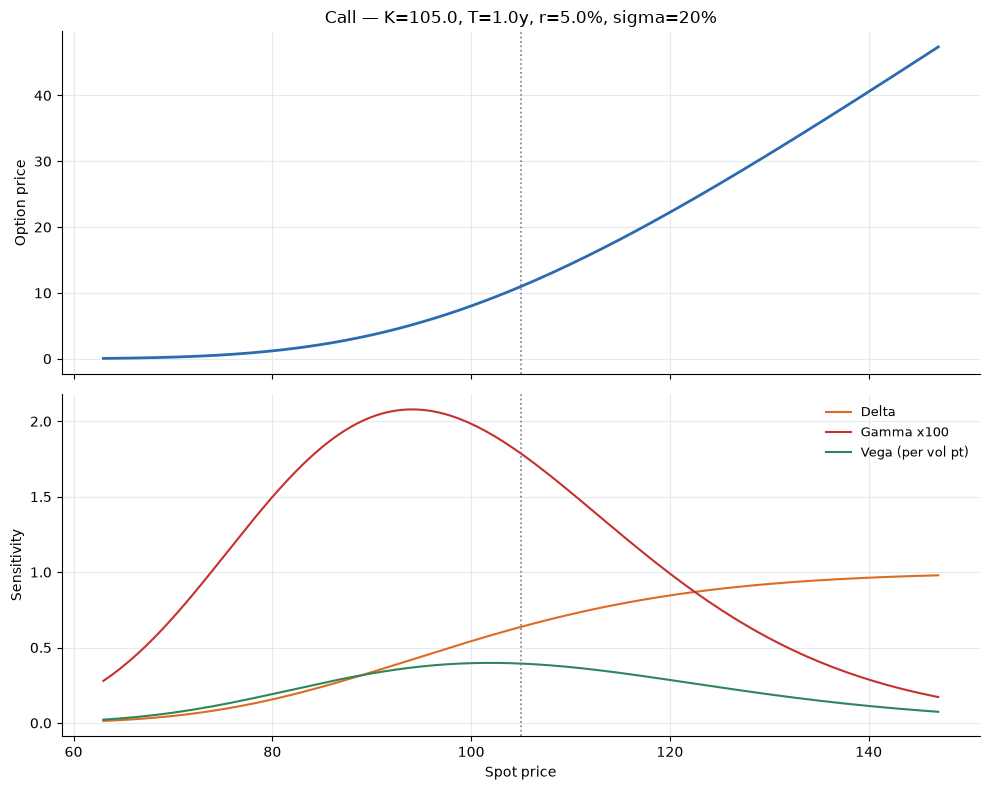

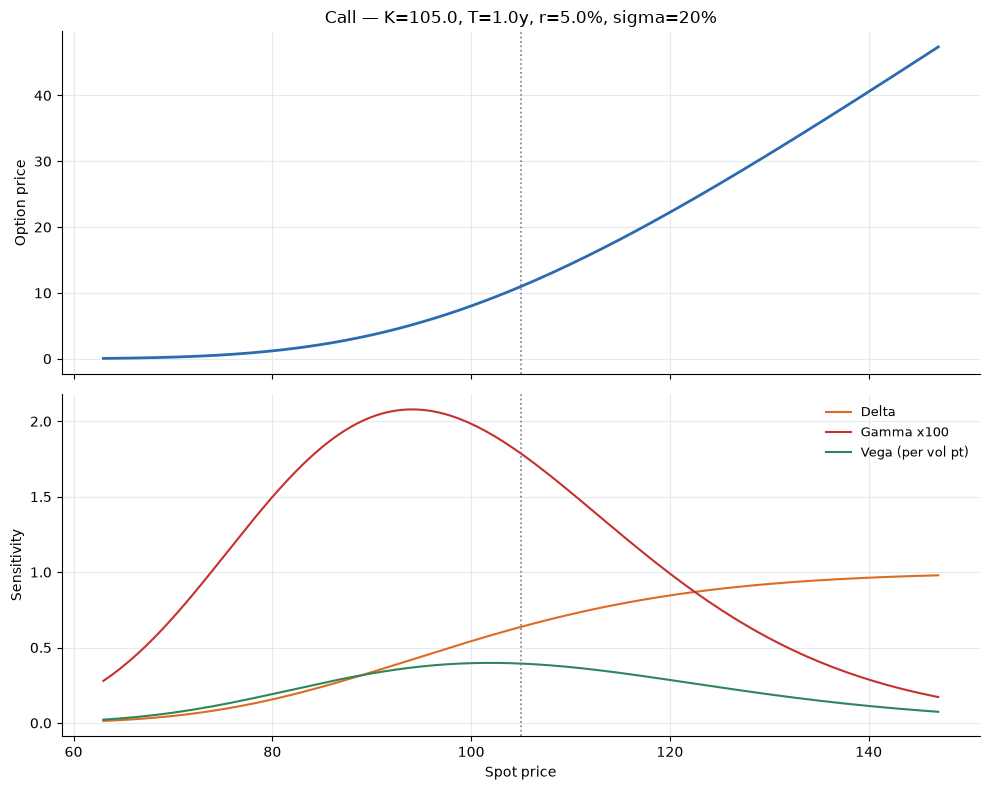

In [6]:
from risk_engine.report import plot_greeks_profile
plot_greeks_profile(strike=K, expiry_years=T, rate=r, volatility=sigma, kind="call")

Gamma peaks at the money and decays either side — that is where a hedger has to
rebalance most often. Vega peaks in the same region: an at-the-money option is
the purest volatility exposure available.

## Implied volatility

In practice volatility is the *output*, not the input: the market quotes a
price and you invert for the vol that reproduces it.

The engine uses Brent's method rather than Newton-Raphson. Price is strictly
increasing in volatility, so once the quote is inside the no-arbitrage bounds a
bracket is guaranteed — Brent then cannot diverge, whereas Newton can when vega
is near zero for deep out-of-the-money options.

In [7]:
for quote in (5.0, 7.566986, 12.0, 20.0):
    iv = implied_volatility(quote, S, K, T, r, "call")
    print(f"market price {quote:6.2f}  ->  implied vol {iv:7.4%}")

market price   5.00  ->  implied vol 12.3964%
market price   7.57  ->  implied vol 18.8550%
market price  12.00  ->  implied vol 30.0586%
market price  20.00  ->  implied vol 50.5440%


In [8]:
# A price below intrinsic value has no implied volatility. The engine says so
# explicitly rather than returning a silently wrong number.
try:
    implied_volatility(0.001, 100.0, 50.0, 1.0, 0.05, "call")
except ValueError as exc:
    print("ValueError:", exc)

ValueError: price 0.001000 is outside the no-arbitrage band [52.438529, 100.000000] for a call


## Early exercise

For an American **put**, early exercise can be optimal — deep in the money, the
strike received now can be reinvested. For an American **call on a
non-dividend-paying stock** it never is (Merton, 1973), so its value equals the
European one. Both facts are asserted in the test suite.

In [9]:
euro_put = binomial_price(100, 120, 1.0, 0.08, 0.3, "put", steps=800, american=False)
amer_put = binomial_price(100, 120, 1.0, 0.08, 0.3, "put", steps=800, american=True)
print(f"European put: {euro_put:.6f}")
print(f"American put: {amer_put:.6f}   early-exercise premium: {amer_put - euro_put:.6f}")

euro_call = binomial_price(100, 95, 1.0, 0.05, 0.25, "call", 0.0, steps=800, american=False)
amer_call = binomial_price(100, 95, 1.0, 0.05, 0.25, "call", 0.0, steps=800, american=True)
print(f"\nEuropean call: {euro_call:.6f}")
print(f"American call: {amer_call:.6f}   difference: {abs(amer_call - euro_call):.2e}")

European put: 18.672815
American put: 21.620354   early-exercise premium: 2.947539

European call: 15.046193
American call: 15.046193   difference: 0.00e+00
